# About Dataset

The Boston Housing dataset is a classic and highly effective resource for practicing Exploratory Data Analysis (EDA), particularly for regression tasks. It captures socio-economic information and housing conditions across 506 census tracts in the Boston area.

The dataset contains a total of **506 samples** (records) and **14 variables**.

### Dataset Structure and Feature Descriptions

The primary goal of working with this dataset is typically to predict the `MEDV` (Median house value) based on the 13 predictor features.

The following table details each of the 14 columns:

| Variable | Definition | Role & Data Type |
|---|---|---|
| **MEDV** | Median value of owner-occupied homes in $1000's | Target Variable (Continuous)  |
| **CRIM** | Per capita crime rate by town | Feature (Continuous) |
| **ZN** | Proportion of residential land zoned for lots over 25,000 sq.ft. | Feature (Continuous) |
| **INDUS** | Proportion of non-retail business acres per town | Feature (Continuous) |
| **CHAS** | Charles River dummy variable (= 1 if tract bounds river; 0 otherwise) | Feature (Categorical/Binary) |
| **NOX** | Nitric oxides concentration (parts per 10 million) | Feature (Continuous)  |
| **RM** | Average number of rooms per dwelling | Feature (Continuous)  |
| **AGE** | Proportion of owner-occupied units built prior to 1940 | Feature (Continuous)  |
| **DIS** | Weighted distances to five Boston employment centres | Feature (Continuous)  |
| **RAD** | Index of accessibility to radial highways | Feature (Discrete/Ordinal)  |
| **TAX** | Full-value property-tax rate per \$10,000 | Feature (Continuous) |
| **PTRATIO** | Pupil-teacher ratio by town | Feature (Continuous)  |
| **B** | $1000(Bk - 0.63)^2$ where $Bk$ is the proportion of Black people by town | Feature (Continuous)  |
| **LSTAT** | % lower status of the population | Feature (Continuous)  |

### Data Quality Note (Relevance to Univariate EDA)

As observed in the file you provided, the dataset contains missing values, represented by "NA". Univariate EDA will be critical for handling these issues, as you will need to:

1.  **Quantify Missingness:** Determine how many values are missing for each feature (`CRIM`, `INDUS`, `CHAS`, `LSTAT`, etc.).
2.  **Evaluate Impact:** Visualize the distribution of the features (like `LSTAT` or `CRIM`) using histograms or boxplots *before* and *after* deciding on an imputation strategy, as missing data can significantly affect summary statistics.
3.  **Check Skewness:** Features like `CRIM` and `LSTAT` often exhibit high skewness, which should be diagnosed early using univariate distributions to determine if a transformation (e.g., log-transformation) is required before moving to modeling.

In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [29]:
df = pd.read_csv("HousingData.csv")

In [30]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


## Phase 1: Data Integrity and Preparation (The Essential Pre-Analysis Check)
Before calculating statistics or drawing plots, the first steps ensure the data is in a usable format and identify immediate quality issues.

## Step 1: Data Type Verification 
Action: Confirm the current data type (e.g., Integer, Float, Object/String) assigned to each of the 14 columns. Why: The statistical and graphical tools used in EDA are entirely dependent on the variable type. For instance, calculating the mean is appropriate for a Continuous variable like RM (Average number of rooms) but meaningless for a Categorical variable like CHAS (Charles River dummy variable). Since the data contains "NA" placeholders for missing values , some columns might be incorrectly read as 'Object' or 'String' types, which must be corrected before calculation.

In [ ]:
df.info()

## Step 2: Missing Value Quantification and Triage
Action: Systematically count the number and percentage of missing values (represented by "NA" in your dataset) for every column, especially for key predictors like CRIM, INDUS, CHAS, and LSTAT. Why: Missing data introduces bias and can corrupt summary statistics. This step provides a crucial integrity diagnostic. A high percentage of missingness might justify dropping a column entirely, while a small percentage might suggest simple imputation (filling in the blanks). You cannot choose a robust imputation strategy without first knowing how much data is missing and where the gaps are.

In [31]:
df.isnull().sum()


CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

In [6]:
missingValues = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'AGE', 'LSTAT']

In [7]:
missing_count = df[missingValues].isnull().sum()
print("Missing Values Count:")
print(missing_count)

Missing Values Count:
CRIM     20
ZN       20
INDUS    20
CHAS     20
AGE      20
LSTAT    20
dtype: int64


In [ ]:
missing_percentage = (df[missingValues].isnull().sum() / len(df)) * 100
print("\nMissing Values Percentage:")
print(missing_percentage)

## Step 3: Categorical Consistency Check
Action: For categorical or binary variables (CHAS and RAD), examine all unique values present. Why: This step ensures that categorical data is correctly recorded. For instance, CHAS should only contain 0 and 1 (representing if the tract bounds the river). If unexpected values (like '2' or 'Y/N') appear, they must be cleaned before using the variable in frequency counts or dummy encoding for a model.

In [ ]:
categoricalColumns = ['CHAS', 'RAD'] 
df[categoricalColumns].isnull().sum()


In [ ]:
categoricalColumns = (df[categoricalColumns].isnull().sum() / len(df)) * 100
print(categoricalColumns)

## Phase 2: Univariate Analysis for Continuous Variables
For numerical features that measure a continuous quantity (CRIM, ZN, NOX, RM, AGE, DIS, TAX, PTRATIO, B, LSTAT, and the target MEDV), the goal is to characterize their distribution, center, and spread.

## Step 4: Descriptive Statistics Calculation
Action: Compute the primary summary statistics for all continuous variables: Mean, Median, Mode, Standard Deviation, Minimum, Maximum, and Quartiles (Q1, Q3, and Interquartile Range or IQR). Why: This provides the core statistical profile.   
Mean vs. Median: Comparing these tells you about the symmetry of the distribution. If the mean is significantly higher than the median, the variable is likely right-skewed (e.g., CRIM), indicating a few very high values are pulling the average up.
Standard Deviation: This quantifies the volatility or spread of the data. A large standard deviation means the data points are widely dispersed.
Minimum and Maximum: These identify impossible or sentinel values (e.g., if AGE were suddenly -5, it indicates a data entry error).

In [ ]:
df.describe()

In [ ]:
continuous_vars = ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'TAX', 'PTRATIO', 'B', 'LSTAT',  'MEDV']


In [ ]:
# Empty dictionary to store results
descriptive_stats = {}

for col in continuous_vars:
    stats = {
        'Count': df[col].count(),
        'Mean': df[col].mean(),
        'Median': df[col].median(),
        'Std Dev': df[col].std(),
        'Min': df[col].min(),
        '25% Quartile': df[col].quantile(0.25),
        '50% Quartile': df[col].quantile(0.5),  # same as median
        '75% Quartile': df[col].quantile(0.75),
        'Max': df[col].max(),
        'Range': df[col].max() - df[col].min()
    }
    descriptive_stats[col] = stats

# Convert to DataFrame for better visualization
descriptive_df = pd.DataFrame(descriptive_stats).T
descriptive_df


## Step 5: Distribution Visualization (Histogram and Density Plot)
Action: Generate a histogram or a kernel density estimation (KDE) plot for each continuous variable (e.g., MEDV, LSTAT). Why: Descriptive statistics alone are insufficient. Visualization is mandatory to understand the shape of the data.   
Normality Check: The plot instantly shows if the variable follows a bell-shaped (normal) distribution, which is often an assumption for linear models.
Skewness and Kurtosis: Histograms visually diagnose skewness (lopsidedness) and kurtosis (heaviness of the tails). Extreme skewness (e.g., high CRIM rate values) must be identified here because it often necessitates a mathematical transformation (like a log transformation) before modeling.

In [ ]:
plt.hist(df["CRIM"],bins=5)

In [ ]:
sns.distplot(df['CRIM'])

In [ ]:
plt.hist(df["ZN"],bins=5)

In [ ]:
sns.distplot(df['ZN'])

In [ ]:
plt.hist(df['INDUS'])

In [ ]:
sns.distplot(df['INDUS'])

In [ ]:
plt.hist(df['NOX'],bins=5)

In [ ]:
sns.distplot(df['NOX'])

In [ ]:
plt.hist(df["RM"],bins=5)

In [ ]:
sns.distplot(df['RM'])

In [ ]:
plt.hist(df["AGE"],bins=5)

In [ ]:
sns.distplot(df['AGE'])

In [ ]:
plt.hist(df["DIS"],bins=5)

In [ ]:
sns.distplot(df['DIS'])

In [ ]:
plt.hist(df["TAX"],bins=5)

In [ ]:
sns.distplot(df['TAX'])

In [ ]:
plt.hist(df["PTRATIO"],bins=5)

In [ ]:
sns.distplot(df['PTRATIO'])

In [ ]:
plt.hist(df["B"],bins=5)

In [ ]:
sns.distplot(df['B'])

In [ ]:
plt.hist(df["LSTAT"],bins=5)

In [ ]:
sns.distplot(df['LSTAT'])

In [ ]:
plt.hist(df["MEDV"],bins=5)

In [ ]:
sns.distplot(df['MEDV'])

## Step 6: Outlier Detection (Boxplot)
Action: Create a boxplot for each continuous variable, paying close attention to the features critical for prediction (RM, LSTAT) and the target variable (MEDV). Why: The boxplot is the authoritative graphical method for visualizing the five-number summary and definitively identifying outliers.   
Influence Check: Outliers in the target variable (MEDV) have disproportionate leverage in regression modeling and may need to be handled (e.g., capping or removal) to improve model robustness.   
Data Spread: It clearly shows the median, the middle 50% of the data (the box, defined by Q1 and Q3), and the extent of the tails.

In [ ]:
sns.boxplot(x=df['CRIM'])

In [ ]:
sns.boxplot(x=df['ZN'])

In [ ]:
sns.boxplot(x=df['INDUS'])

In [ ]:
sns.boxplot(x=df['NOX'])

In [ ]:
sns.boxplot(x=df['RM'])

In [ ]:
sns.boxplot(x=df['AGE'])

In [ ]:
sns.boxplot(x=df['DIS'])

In [ ]:
sns.boxplot(x=df['TAX'])

In [ ]:
sns.boxplot(x=df['PTRATIO'])

In [ ]:
sns.boxplot(x=df['B'])

In [ ]:
sns.boxplot(x=df['LSTAT'])

In [ ]:
sns.boxplot(x=df['MEDV'])

## Phase 3: Univariate Analysis for Categorical and Discrete Variables
For variables that represent distinct groups (CHAS) or counts (RAD), the focus shifts to frequency and proportion.

## Step 7: Frequency Analysis (Countplot/Bar Chart)
Action: Generate a bar chart (or countplot) and a frequency table for the categorical variables (CHAS and RAD). Why: This immediately reveals the distribution and potential class imbalance.   
Class Imbalance: For CHAS (Charles River dummy), the bar chart will quickly show that tracts bounding the river (CHAS=1) are a minority. Severe imbalance can bias a classification model, and this visual confirmation guides the need for specific sampling techniques later.   
Modal Category: The frequency table identifies the most common value (the Mode) for each variable. For RAD (accessibility index), this shows which highway index is most common across the Boston tracts.

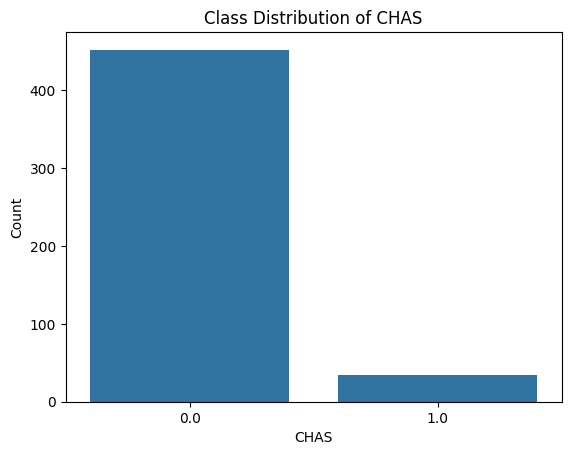

In [49]:
sns.countplot(x='CHAS', data=df)
plt.title('Class Distribution of CHAS')
plt.xlabel('CHAS')
plt.ylabel('Count')
plt.show()


In [50]:
# Calculate mode for RAD
rad_mode = df['RAD'].mode()[0]
print(f"The most common RAD value is: {rad_mode}")


The most common RAD value is: 24


In [51]:
rad_freq = df['RAD'].value_counts()
print(rad_freq)


RAD
24    132
5     115
4     110
3      38
6      26
8      24
2      24
1      20
7      17
Name: count, dtype: int64


In [ ]:
# 2. Handling Missing Values
# dataset has missing values in columns like CRIM, ZN, INDUS, etc.
# We will fill them with the median value of each column.
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

In [33]:
df_imputed.isnull().sum()


CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [34]:
# 3. Define Features (X) and Target (y)
X = df_imputed.drop('MEDV', axis=1)  # Features (all columns except price)
y = df_imputed['MEDV']               # Target (price)

In [35]:
# 4. Split Data into Training and Testing Sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:
# 5. Train the Model (Random Forest)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
# 6. Make Predictions and Evaluate
predictions = model.predict(X_test)

In [45]:
# Calculate Accuracy (R-squared) and Error (RMSE)
r2 = r2_score(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

In [43]:
print(f"Model Accuracy (R² Score): {r2:.2f}") # Closer to 1.0 is better
print(f"Prediction Error (RMSE): {rmse:.2f}") # Lower is better

Model Accuracy (R² Score): 0.89
Prediction Error (RMSE): 2.87
